In [ ]:
import os
import os.path
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive')
import binvox_rw

In [ ]:
# file_path='/content/drive/MyDrive/4_rectangular_passage_750_more/4_78.binvox'

In [ ]:
import os
file_paths=[]
directory = '/content/drive/MyDrive/Featurenet_exp/names'

with open(os.path.join(directory, 'file_paths.txt'), 'r') as f:
    file_paths = [line.strip() for line in f]

In [ ]:
file_paths[0]

'/content/drive/MyDrive/Featurenet_exp/all_files_ziped_64/0_1.binvox'

In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_3d_array(fp)
       model.data
       '''
       to get a 3d array write model.data
       '''

In [ ]:
model.dims

[256, 256, 256]

In [ ]:
'''
extracting the label as our files are 11_989.binvox implying the label is 11
'''

binvox_file_path = '/content/12_503.binvox'



with open(binvox_file_path, 'rb') as binvox_file:
    # Extract the filename from the path
    file_name = os.path.basename(binvox_file.name)
    label=file_name.split('_')[0]
    label=int(label)

    print (type(label))
    print("File name:", label)


<class 'int'>
File name: 12


## Understanding Binvox file format

In [ ]:
    '''
    Checking if its a binvox file,how binvox file is read , the below code runs for 4 times ,giving the file
    ##so every line it reads it strips that line and then the next line becomes the first line , we are technically remving data
    ##We can read binary data with data_raw here which is file.read()
    this is how a binvox file looks like
    #binvox 1
    dim 256 256 256
   translate 0 0 0
   scale 10
   data
   b'\x01\xff\x01\xff\x01\xff\x01\xff\x01\xff\x01\xff\x01\xff\x01\xff\x01\xff\x01

    '''

    with open(file_path, 'rb') as f:
        # Read the first line which contains the Binvox header
        line = f.readline().decode().strip()
        print(line)
        if line != '#binvox 1':
           raise ValueError("Not a valid binvox file")
        dims = None
        scale = None
        translate = None
        data = []
        print(line)
        while True:


            line = f.readline().decode().strip()
            if not line:
                break
            elif line.startswith('dim'):
                dims = tuple(map(int, line.split()[1:]))
                print(line)
                #print(dims)
            elif line.startswith('translate'):
                translate = tuple(map(float, line.split()[1:]))
                #print(line)
                #print(translate)
            elif line.startswith('scale'):
                scale = float(line.split()[1])
                #print(line)
            elif line.startswith('data'):
                data_start = f.tell()
                data_raw = f.read()
                data.extend(data_raw)
                #print(line)
                #print(data)

                ##print(data_raw) ## raw data starts with b'
            if dims is None:
              raise ValueError("Dimensions not specified in binvox file")
            voxels = np.unpackbits(np.array(data, dtype=np.uint8))
            #print(line)




#binvox 1
#binvox 1
dim 256 256 256


## Viewing a 2d slice of our data

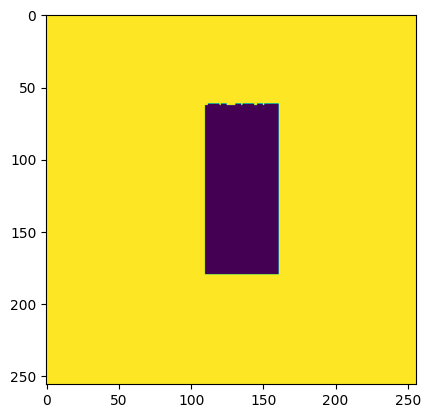

In [ ]:
'''
Showing multiple axis views , We can view there is a slot when we view from the z axis
'''

plt.imshow(model.data[:,0,:])
plt.imshow(model.data[0,:,:])
plt.imshow(model.data[:,:,0])

In [ ]:
with open('/content/0_1.binvox','rb') as fp :
  model = binvox_rw.read_as_3d_array(fp)
  print(fp)
  #tf.convert_to_tensor(model.data)

<_io.BufferedReader name='/content/0_1.binvox'>


In [ ]:
'''
not working well
'''
def parse_record(record):
        record_bytes = tf.io.decode_raw(record, tf.uint8)

        label = tf.cast(record_bytes[0:label_bytes], tf.int32)
        print(label)
        return label
img_width = 256
img_height = 256
img_depth = 256
label_bytes = 1
image_bytes = img_width * img_height * img_depth

with open ('/content/7_3.binvox','rb') as fp:
  parse_record(fp.readline())

tf.Tensor([35], shape=(1,), dtype=int32)


## Plotting the file in 3d

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

using filepath index 17777, which is a rectangular through hole


In [ ]:
file_path=file_paths[17777]
print(file_path)

/content/drive/MyDrive/Featurenet_exp/all_files_ziped_64/4_799.binvox


In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_coord_array(fp)
       model.data


In [ ]:
data=model.data
data.shape

(3, 228352)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from binvox_rw import read_as_3d_array

# Path to your binvox file
# binvox_file = 'path/to/your/file.binvox'

# Read the binvox file
with open(file_path, 'rb') as f:
    voxel = read_as_3d_array(f)

# Extract voxel data and dimensions
voxels = voxel.data
size = voxel.dims



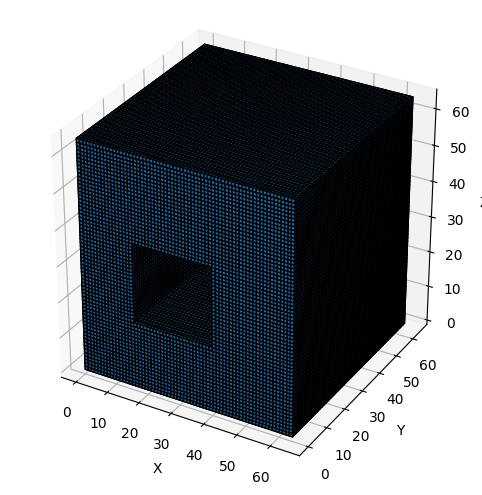

In [ ]:
'''
Used to create 3d representation of the voxel data
'''

# Create a figure and axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot voxels
ax.voxels(voxels, edgecolor='k')


# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal

# Show plot
plt.show()


In [ ]:
# data_shape = data.shape
# xs = data[0]  # x-coordinates
# ys = data[1]  # y-coordinates
# zs = data[2]  # z-coordinates

# # Create a figure and a 3D Axes
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Plot scatter plot
# ax.scatter( ys,xs, zs)

# # Set labels
# ax.set_xlabel('X Label')
# ax.set_ylabel('Y Label')
# ax.set_zlabel('Z Label')

# plt.show()

In [ ]:
# ax = plt.axes(projection='3d')
# x_data=np.random.randint(0,100,(500,))
# y_data=np.random.randint(0,100,(500,))
# z_data=np.random.randint(0,100,(500,))

# ax.scatter(x_data,y_data,z_data)
# plt.show()


In [ ]:
# with open(file_path, 'rb') as f:
#     voxel = binvox_rw.read_as_3d_array(f)

# # Extract voxel data and dimensions
# voxels = voxel.data
# size = voxel.dims
# print(size)

In [ ]:
# import tkinter as tk
# from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
# from matplotlib.figure import Figure

# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from binvox_rw import read_as_3d_array

In [ ]:
# # Create a figure
# fig = plt.figure(figsize=(8, 6))

# # Create a 3D axis
# ax = fig.add_subplot(111, projection='3d')

# # Plot voxels
# ax.voxels(voxels, edgecolor='k')

# # Set the labels
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')

# # Set the aspect ratio to be equal
# ax.set_box_aspect([1, 1, 1])

# # Show plot
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import ipywidgets as widgets
# from IPython.display import display

# # Generate example voxel data (replace this with your actual voxel data loading)
# # voxels = np.random.randint(0, 2, size=(64, 64, 64), dtype=bool)
# voxels=voxel.data

# # Function to update the plot based on slider values
# def update_plot(x_slice, y_slice, z_slice):
#     fig.clear()
#     ax = fig.add_subplot(111, projection='3d')

#     # Plot voxels
#     ax.voxels(voxels, edgecolor='k')

#     # Set labels
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')

#     # Set aspect ratio to be equal
#     ax.set_box_aspect([1, 1, 1])

#     # Display plot
#     plt.show()

# # Create sliders for x, y, and z slices
# x_slider = widgets.IntSlider(min=0, max=63, value=31, description='X Slice')
# y_slider = widgets.IntSlider(min=0, max=63, value=31, description='Y Slice')
# z_slider = widgets.IntSlider(min=0, max=63, value=31, description='Z Slice')

# # Display sliders
# display(x_slider, y_slider, z_slider)

# # Create a matplotlib figure
# fig = plt.figure(figsize=(8, 6))

# # Initialize the plot with default slider values
# update_plot(x_slider.value, y_slider.value, z_slider.value)

# # Update the plot when sliders change
# widgets.interactive(update_plot, x_slice=x_slider, y_slice=y_slider, z_slice=z_slider)



## Plotting using x,y,z coordinates


In [ ]:
file_path=file_paths[17777]
print(file_path)
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_coord_array(fp)
       cords=model.data


/content/drive/MyDrive/Featurenet_exp/all_files_ziped_64/4_799.binvox


In [ ]:
print(f"shape : {cords.shape}  ")

shape : (3, 71411)  


In [ ]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
plt.style.use('seaborn-poster')

<ipython-input-79-b6c5a12a25f7>:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-poster')


In [ ]:
x=cords[0,:]
y=cords[1,:]
z=cords[2,:]
print(x.shape)

(71411,)


In [ ]:
print (f" bottom edge : {x[0],y[0],z[0]} ")
# print (f" diagnoal to bottom edge : {x[228351],y[228351],z[228351]} ")

 bottom edge : (0.001220703125, 5.0, 0.078125) 


In [ ]:
((64*64*64)-228353)/(64*64*64)

0.12890243530273438

In [ ]:
np.argmax(x),np.argmax(y),np.argmax(z)

(228351, 63, 4095)

In [ ]:
x

array([1.22070312e-03, 1.46484375e-03, 1.70898438e-03, ...,
       6.39882812e+01, 6.39885254e+01, 6.39887695e+01])

In [ ]:
x[228351],y[228351],z[228351]

(63.999755859375, 63.0, 63.984375)

In [ ]:
np.min(binvox_rw.sparse_to_dense(cords,dims=64))

False

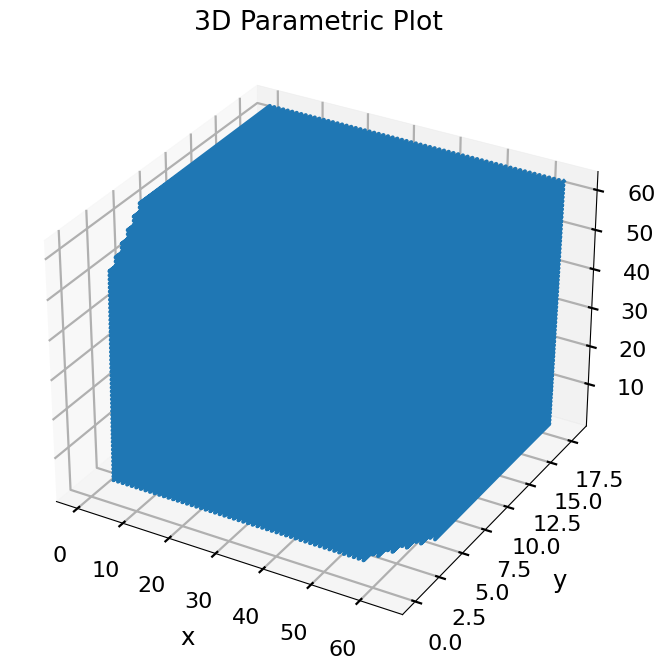

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection='3d')
ax.grid()


ax.plot3D(x, y, z)
ax.set_title('3D Parametric Plot')

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

plt.show()

In [ ]:
def read_header(fp):
    """ Read binvox header. Mostly meant for internal use.
    """
    line = fp.readline().strip()
    if not line.startswith(b'#binvox'):
        raise IOError('Not a binvox file')
    dims = list(map(int, fp.readline().strip().split(b' ')[1:]))
    translate = list(map(float, fp.readline().strip().split(b' ')[1:]))
    scale = list(map(float, fp.readline().strip().split(b' ')[1:]))[0]
    line = fp.readline()
    return dims, translate, scale

In [ ]:
with open(file_path, 'rb') as fp:
  dims, translate, scale = read_header(fp)
  raw_data = np.frombuffer(fp.read(), dtype=np.uint8)

  values, counts = raw_data[::2], raw_data[1::2]

In [ ]:
# print(dims)
print(np.unique(values),np.unique(counts))
print(counts.shape)

[0 1] [133 135 138 255]
(1051,)


In [ ]:
sz = np.prod(dims)
print(sz==(64*64*64))

True


In [ ]:
index, end_index = 0, 0
end_indices = np.cumsum(counts)
(np.unique(end_indices)).shape
np.unique(end_indices==counts,return_counts=True)

(array([False,  True]), array([1050,    1]))

In [ ]:
    indices = np.concatenate(([0], end_indices[:-1])).astype(end_indices.dtype)


In [ ]:
values = values.astype(bool)
indices = indices[values]
end_indices = end_indices[values]

In [ ]:
np.unique(values,return_counts=True)

(array([False,  True]), array([144, 907]))

In [ ]:
# (np.unique(indices,return_counts=True))

In [ ]:
np.unique(values,return_counts=True)

(array([False,  True]), array([144, 907]))

In [ ]:
    nz_voxels = []
    for index, end_index in zip(indices, end_indices):
        nz_voxels.extend(range(index, end_index))
    nz_voxels = np.array(nz_voxels)

In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_3d_array(fp)
       voxels=model.data

In [ ]:
voxels.shape,np.unique(voxels,return_counts=True)

((64, 64, 64), (array([False,  True]), array([ 33792, 228352])))

In [ ]:
def find_first_zero(voxels):
    for i in range(64):
        for j in range(64):
            for k in range(64):
                if voxels[i, j, k] == 0:
                    print(i, j, k)
                    return i, j, k

In [ ]:
voxels[16, 0 ,63]

True

In [ ]:
find_first_zero(voxels)

16 0 18


(16, 0, 18)

In [ ]:
def all_zeros_coordinates (voxels,x,y,z):
    for i in range(64):
        for j in range(64):
            for k in range(64):
                if voxels[i, j, k] == 0:
                  x.append(i)
                  y.append(j)
                  z.append(k)


    return x,y,z

In [ ]:
x=[]
y=[]
z=[]
x,y,z=all_zeros_coordinates(voxels,x,y,z)

In [ ]:
len(x),len(y),len(z)

(33792, 33792, 33792)

In [ ]:
temp=1000
voxels[x[temp],y[temp],z[temp]]

False

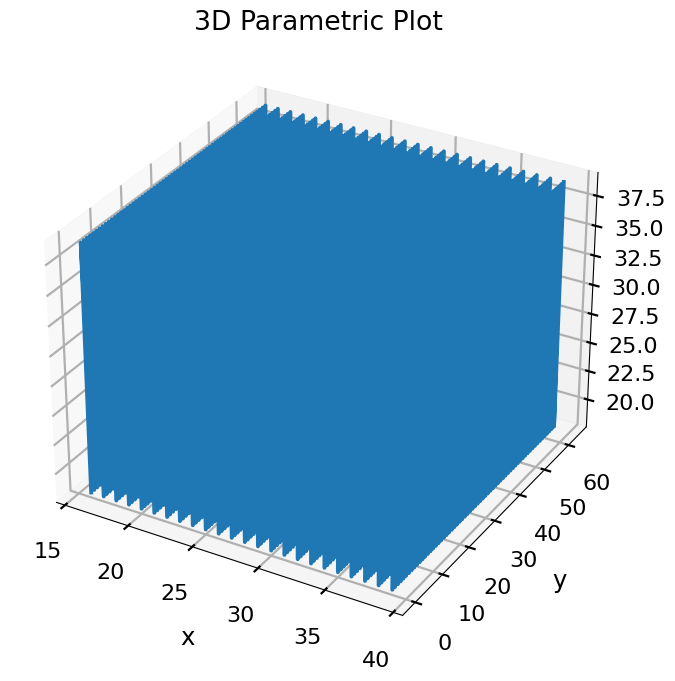

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection='3d')
ax.grid()


ax.plot3D(x, y, z)
ax.set_title('3D Parametric Plot')

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

plt.show()

In [ ]:
temp=1004

x[temp],y[temp],z[temp]


(16, 45, 32)

In [ ]:
'''
It is a through swuare pocket type of thing
'''
print(np.min(x),np.min(y),np.min(z))
print(np.max(x),np.max(y),np.max(z))

16 0 18
39 63 39


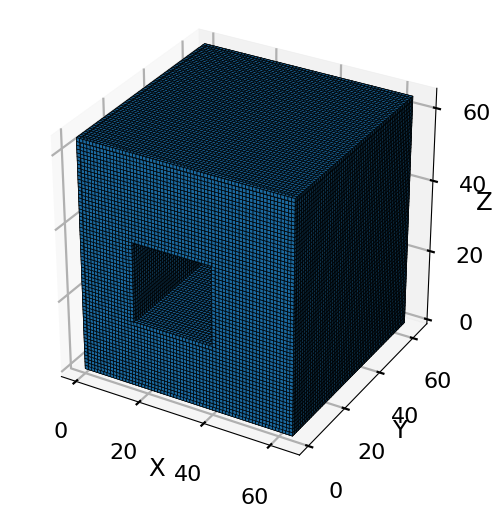

In [ ]:
'''
Used to create 3d representation of the voxel data
'''

# Create a figure and axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot voxels
ax.voxels(voxels, edgecolor='k')
ax.plot3D(x, y, z)

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal

# Show plot
plt.show()


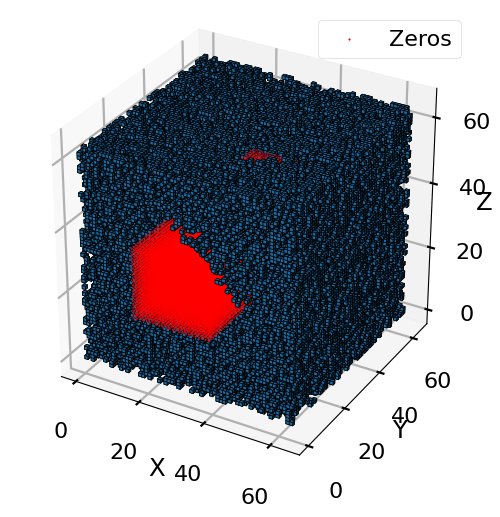

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Extract coordinates of zeros
# zero_coords = np.argwhere(voxels == 0)
# x, y, z = zero_coords[:, 0], zero_coords[:, 1], zero_coords[:, 2]

# Create a figure and axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the voxel data
ax.voxels(voxels, edgecolor='k')

# Overlay the zero coordinates
ax.scatter(x, y, z, color='red', s=1, label='Zeros')

# Set labels and aspect ratio
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([1, 1, 1])  # Set aspect ratio to be equal
ax.legend()

# Show plot
plt.show()


In [ ]:
len(x)

33792

In [ ]:
np.sum(x)

929280

In [ ]:
def get_com (x,y,z):
    return np.sum(x)/len(x),np.sum(y)/len(y),np.sum(z)/len(z)

In [ ]:
cord_x,cord_y,cord_z=get_com(x,y,z)

27.5

In [ ]:
with open(file_path, 'rb') as fp:
       model = binvox_rw.read_as_3d_array(fp)
       voxels=model.data

In [ ]:
voxels.shape

(64, 64, 64)

In [ ]:
voxels[int(cord_x),int(cord_y),int(cord_z)]

False

In [ ]:
'''
Assuming the 0 th direction is x , 1st is y and 3 rd is z

'''
def get_axis(voxels_data):
  x=0
  y=0
  z=0
  axis=[]
  if np.any(voxels_data[0,:,:]==0):
    x=1
  if np.any(voxels_data[:,0,:]==0):
    y=1
  if np.any(voxels_data[:,:,0]==0):
    z=1
  if x==1:
    axis.append('x-axis')
  if y==1:
    axis.append('y-axis')
  if z==1:
    axis.append('z-axis')
  return axis

get_axis(voxels)

['y-axis']

In [ ]:
def get_depth(voxels_data,axis,x_cords,y_cords,z_cords):
  depth=[]
  for i in range(len(axis)):
    if axis[i]=='x-axis':
      depth.append(np.max(x_cords))
    if axis[i]=='y-axis':
      depth.append(np.max(y_cords))
    if axis[i]=='z-axis':
      depth.append(np.max(z_cords))
  return depth


In [ ]:
get_depth(voxels,get_axis(voxels),x,y,z)

[63]

## Function to get voxel cutting information

In [ ]:
def all_zeros_coordinates (voxels,x,y,z):

    for i in range(64):
        for j in range(64):
            for k in range(64):
                if voxels[i, j, k] == 0:
                  x.append(i)
                  y.append(j)
                  z.append(k)


    return x,y,z

In [ ]:
def get_com (x,y,z):
    return np.sum(x)/len(x),np.sum(y)/len(y),np.sum(z)/len(z)

In [ ]:
'''
Assuming the 0 th direction is x , 1st is y and 3 rd is z

'''
def get_axis(voxels_data):
  x=0
  y=0
  z=0
  axis=[]
  if np.any(voxels_data[0,:,:]==0):
    x=1
  if np.any(voxels_data[:,0,:]==0):
    y=1
  if np.any(voxels_data[:,:,0]==0):
    z=1
  if x==1:
    axis.append('x-axis')
  if y==1:
    axis.append('y-axis')
  if z==1:
    axis.append('z-axis')
  return axis

get_axis(voxels)

['y-axis']

In [ ]:
def get_depth(voxels_data,axis,x_cords,y_cords,z_cords):
  depth=[]
  for i in range(len(axis)):
    if axis[i]=='x-axis':
      depth.append(np.max(x_cords))
    if axis[i]=='y-axis':
      depth.append(np.max(y_cords))
    if axis[i]=='z-axis':
      depth.append(np.max(z_cords))
  return depth


In [ ]:
def get_voxel_information(voxels_data):
  axis=[]
  x_cords=[]
  y_cords=[]
  z_cords=[]
  depth=[]

  x_cords,y_cords,z_cords=all_zeros_coordinates(voxels_data,x_cords,y_cords,z_cords)
  x_com,y_com,z_com=get_com(x_cords,y_cords,z_cords)
  axis=get_axis(voxels_data)
  depth=get_depth(voxels_data,axis,x_cords,y_cords,z_cords)
  print(f"x_com : {x_com}  y_com : {y_com} z_com : {z_com}")
  print(f"axis : {axis}")
  print(f"depth : {depth}")
  return x_com,y_com,z_com,axis,depth





In [ ]:
get_voxel_information(voxels)

x_com : 27.5  y_com : 31.5 z_com : 28.5
axis : ['y-axis']
depth : [63]


(27.5, 31.5, 28.5, ['y-axis'], [63])